# 04 — Age-Period-Cohort Patterns in Opioid Misuse and OUD

Visualize how opioid misuse prevalence varies by **age group** across
**survey years** (2002–2023), using fine-grained age groups from the
NSDUH PUF microdata.

Four outcomes:
1. **Any opioid misuse** — heroin use or prescription opioid misuse (past year)
2. **Opioid use disorder (OUD)** — DSM-IV (2002–2020) or DSM-5 (2021+)
3. **Opioid misuse without OUD** — misuse among the non-OUD population
4. **Former opioid misuse** — lifetime misuse but NOT past-year misuse

Each plot shows age groups on the x-axis, with dots spread left-to-right
within each group by survey year. This layout reveals age, period, and
cohort effects simultaneously:
- **Age effects**: the shape of the curve across age groups in any given year
- **Period effects**: vertical shifts affecting all ages in a given year
- **Cohort effects**: diagonal patterns as birth cohorts age through time

**Prerequisite:** Run notebook 03 first to generate `data/derived/nsduh_combined_puf.parquet`.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

DATA_DIR = Path(os.path.abspath(os.path.join('..', 'data')))
DERIVED_DIR = DATA_DIR / 'derived'

puf_path = DERIVED_DIR / 'nsduh_combined_puf.parquet'
df = pd.read_parquet(puf_path)
print(f'Loaded {len(df):,} rows, {df.year.nunique()} years ({df.year.min()}–{df.year.max()})')
print(f'Columns: {df.columns.tolist()}')

Loaded 1,212,122 rows, 22 years (2002–2023)
Columns: ['year', 'weight', 'stratum', 'replicate', 'age_fine_label', 'age_label', 'sex_label', 'race_label', 'any_opioid_misuse', 'opioid_use_disorder', 'fentanyl_use', 'fentanyl_misuse', 'lifetime_opioid_misuse', 'former_opioid_misuse']


In [2]:
# Construct: opioid misuse among non-OUD population
# Filter to respondents where both variables are non-missing,
# then restrict to those WITHOUT OUD, and measure misuse prevalence.
both_valid = df['any_opioid_misuse'].notna() & df['opioid_use_disorder'].notna()
print(f'Both misuse and OUD available: {both_valid.sum():,} / {len(df):,} '
      f'({both_valid.mean()*100:.1f}%)')

# Create the outcome: misuse==1 among people with OUD==0
# For people with OUD==1, this is NaN (they're excluded from the denominator)
df['misuse_no_oud'] = np.where(
    ~both_valid, np.nan,
    np.where(df['opioid_use_disorder'] == 1, np.nan,  # exclude OUD cases
             df['any_opioid_misuse'])  # 1 if misusing, 0 if not
)

# Former opioid misuse is already computed in notebook 03
# (lifetime_opioid_misuse==1 AND any_opioid_misuse==0)
print(f'Former opioid misuse available: '
      f'{df["former_opioid_misuse"].notna().sum():,} / {len(df):,}')

# Check coverage
for outcome in ['any_opioid_misuse', 'opioid_use_disorder', 'misuse_no_oud',
                'former_opioid_misuse']:
    valid = df.groupby('year')[outcome].apply(lambda s: s.notna().mean())
    yrs = valid[valid > 0.5].index.tolist()
    print(f'{outcome}: {len(yrs)} years')

Both misuse and OUD available: 1,212,122 / 1,212,122 (100.0%)
Former opioid misuse available: 1,183,367 / 1,212,122
any_opioid_misuse: 22 years
opioid_use_disorder: 22 years
misuse_no_oud: 22 years


former_opioid_misuse: 22 years


In [3]:
def weighted_prev(df, outcome, wt='weight', strat='stratum', rep='replicate'):
    """Compute weighted prevalence with paired-jackknife SE."""
    d = df.dropna(subset=[outcome, wt])
    if len(d) == 0:
        return {'prev': np.nan, 'se': np.nan, 'ci_lo': np.nan, 'ci_hi': np.nan,
                'n': 0, 'n_wt': 0}
    
    w = d[wt].values.astype(float)
    y = d[outcome].values.astype(float)
    theta = np.average(y, weights=w)
    
    se = np.nan
    if strat in d.columns and rep in d.columns:
        sv = d[strat].values
        rv = d[rep].values
        var_sum = 0.0
        for h in np.unique(sv[~np.isnan(sv)]):
            in_h = sv == h
            if np.unique(rv[in_h]).size < 2:
                continue
            w_r = w.copy()
            w_r[in_h & (rv == 1)] *= 2
            w_r[in_h & (rv == 2)] = 0
            if w_r.sum() > 0:
                theta_r = np.average(y, weights=w_r)
                var_sum += (theta_r - theta) ** 2
        se = np.sqrt(var_sum)
    
    ci_lo = max(0, theta - 1.96 * se) if not np.isnan(se) else np.nan
    ci_hi = min(1, theta + 1.96 * se) if not np.isnan(se) else np.nan
    
    return {'prev': theta, 'se': se, 'ci_lo': ci_lo, 'ci_hi': ci_hi,
            'n': len(d), 'n_wt': w.sum()}

def prevalence_table(df, outcome, group_cols):
    """Compute prevalence for each group."""
    rows = []
    for name, grp in df.groupby(group_cols, dropna=False):
        if not isinstance(name, tuple):
            name = (name,)
        if grp[outcome].notna().sum() == 0:
            continue
        est = weighted_prev(grp, outcome)
        row = dict(zip(group_cols, name))
        row['outcome'] = outcome
        row.update(est)
        rows.append(row)
    return pd.DataFrame(rows)

In [4]:
# Compute fine-age estimates for all four outcomes
outcomes = {
    'any_opioid_misuse': 'Any Opioid Misuse (Past Year)',
    'opioid_use_disorder': 'Opioid Use Disorder',
    'misuse_no_oud': 'Opioid Misuse among Non-OUD Population',
    'former_opioid_misuse': 'Former Opioid Misuse (Lifetime Yes, Past-Year No)',
}

results = {}
for outcome, label in outcomes.items():
    print(f'{label}...', end=' ')
    t = prevalence_table(df, outcome, ['year', 'age_fine_label'])
    results[outcome] = t
    print(f'{len(t)} cells')

print(f'\nDone: {sum(len(v) for v in results.values())} total estimates')

Any Opioid Misuse (Past Year)... 

220 cells
Opioid Use Disorder... 

220 cells
Opioid Misuse among Non-OUD Population... 

220 cells
Former Opioid Misuse (Lifetime Yes, Past-Year No)... 

220 cells

Done: 880 total estimates


In [5]:
def comparability_period(year):
    if year <= 2014: return '2002-2014 (DSM-IV, in-person)'
    if year <= 2019: return '2015-2019 (DSM-5, in-person)'
    if year == 2020: return '2020 (COVID disrupted)'
    return '2021+ (DSM-5, multimode)'

period_colors = {
    '2002-2014 (DSM-IV, in-person)': 'steelblue',
    '2015-2019 (DSM-5, in-person)': 'darkorange',
    '2020 (COVID disrupted)': 'gray',
    '2021+ (DSM-5, multimode)': 'crimson',
}

FINE_AGE_ORDER = ['12-13', '14-15', '16-17', '18-20', '21-25', '26-29',
                  '30-34', '35-49', '50-64', '65+']

def plot_age_profile(est_df, outcome_label, age_col='age_fine_label',
                     age_order=FINE_AGE_ORDER, figsize=(14, 7)):
    """Age-profile plot: prevalence by age group, dots spread by year."""
    d = est_df.copy()
    d['pct'] = d['prev'] * 100
    d['lo'] = d['ci_lo'] * 100
    d['hi'] = d['ci_hi'] * 100
    d = d.dropna(subset=[age_col, 'pct'])
    d['age_rank'] = d[age_col].map({a: i for i, a in enumerate(age_order)})
    d = d.dropna(subset=['age_rank']).sort_values(['age_rank', 'year'])
    d['period'] = d['year'].apply(comparability_period)
    
    fig, ax = plt.subplots(figsize=figsize)
    ages = [a for a in age_order if a in d[age_col].values]
    age_positions = {a: i for i, a in enumerate(ages)}
    years = sorted(d['year'].unique())
    n_years = len(years)
    spread = 0.6
    
    # Precompute x positions
    xy = {}
    for _, row in d.iterrows():
        age = row[age_col]
        yr = int(row['year'])
        yr_idx = years.index(yr)
        x = age_positions[age] + (yr_idx / (n_years - 1) - 0.5) * spread if n_years > 1 else age_positions[age]
        xy[(age, yr)] = (x, row['pct'], row['lo'], row['hi'], row['period'])
    
    # Light lines connecting same age group across years (within period)
    for age in ages:
        prev_point = None
        prev_period = None
        for yr in years:
            if (age, yr) not in xy:
                prev_point = None
                continue
            x, y, lo, hi, period = xy[(age, yr)]
            if prev_point is not None and prev_period == period:
                ax.plot([prev_point[0], x], [prev_point[1], y],
                        '-', color=period_colors.get(period, 'gray'), alpha=0.25, linewidth=0.8)
            prev_point = (x, y)
            prev_period = period
    
    # Light lines connecting same year across age groups
    for yr in years:
        pts = [(xy[(age, yr)][0], xy[(age, yr)][1], xy[(age, yr)][4])
               for age in ages if (age, yr) in xy]
        if len(pts) > 1:
            color = period_colors.get(pts[0][2], 'gray')
            xs = [p[0] for p in pts]
            ys = [p[1] for p in pts]
            ax.plot(xs, ys, '-', color=color, alpha=0.15, linewidth=0.6)
    
    # Dots and error bars
    for (age, yr), (x, y, lo, hi, period) in xy.items():
        color = period_colors.get(period, 'gray')
        ax.plot(x, y, 'o', color=color, markersize=4, alpha=0.7)
        ax.plot([x, x], [lo, hi], '-', color=color, alpha=0.3, linewidth=0.8)
    
    ax.set_xticks(range(len(ages)))
    ax.set_xticklabels(ages, rotation=45)
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Prevalence (%)')
    ax.set_title(f'{outcome_label} by Age Group — All Years\n'
                 f'(dots spread left\u2192right = {years[0]}\u2192{years[-1]})')
    legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                              label=p, markersize=8) for p, c in period_colors.items()]
    ax.legend(handles=legend_elements, fontsize=8, loc='upper right')
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    return fig

## Any Opioid Misuse by Age Group

Heroin use or prescription opioid misuse (excludes prescribed use under
medical care). Questionnaire redesign at 2015; otherwise consistent.

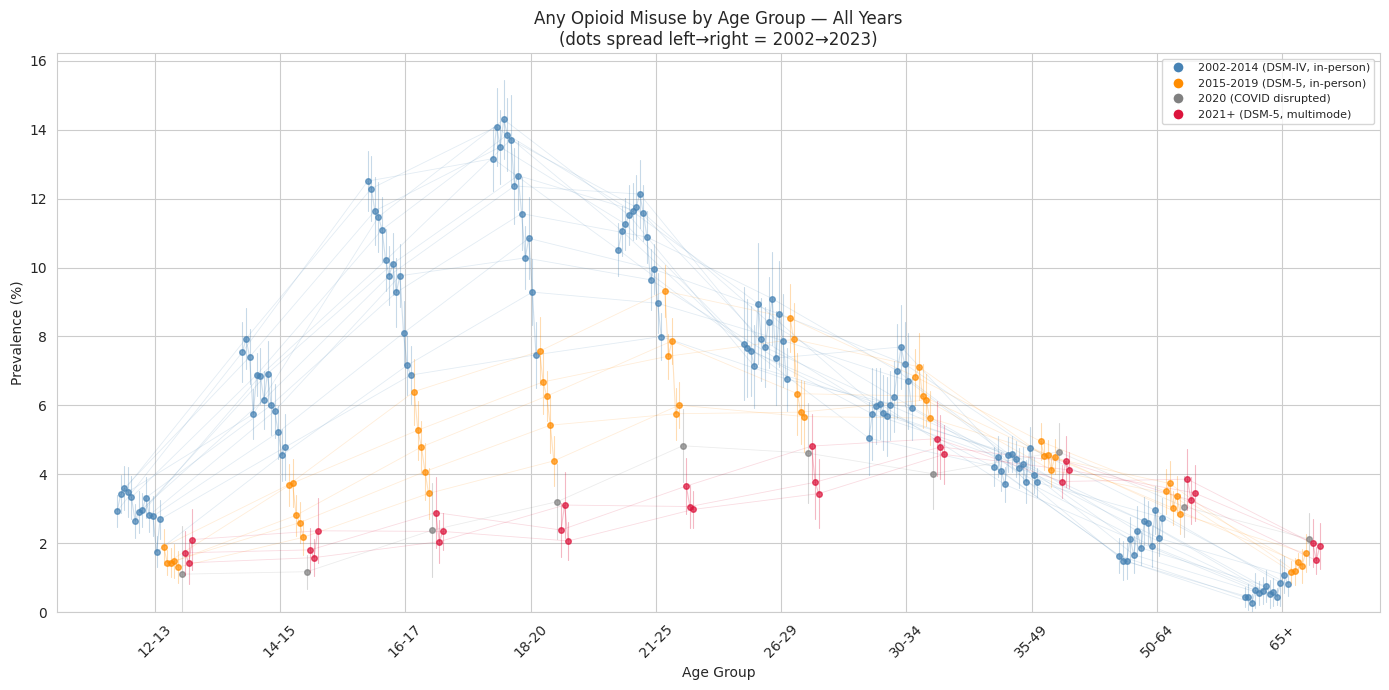

In [6]:
fig = plot_age_profile(results['any_opioid_misuse'], 'Any Opioid Misuse')
plt.show()

## Opioid Use Disorder by Age Group

DSM-IV abuse/dependence (2002–2020) or DSM-5 OUD (2021+).
The jump at 2021 reflects the broader DSM-5 criteria, not a real
increase. Within each era the estimates are comparable.

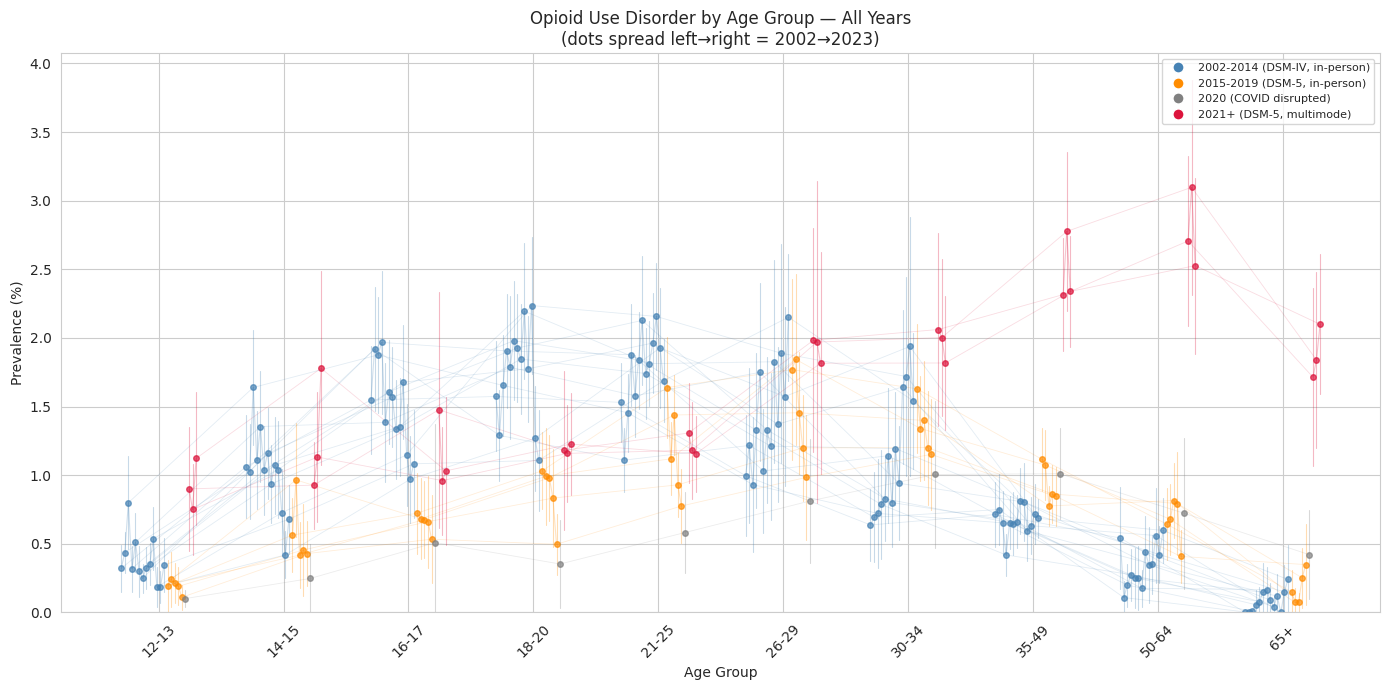

In [7]:
fig = plot_age_profile(results['opioid_use_disorder'], 'Opioid Use Disorder')
plt.show()

## Opioid Misuse among the Non-OUD Population

Prevalence of opioid misuse among people who do **not** meet criteria
for opioid use disorder. This captures "recreational" or occasional
misuse that has not (yet) progressed to a diagnosable disorder.

The denominator excludes anyone with OUD, so this is
P(misuse | no OUD), not P(misuse AND no OUD).

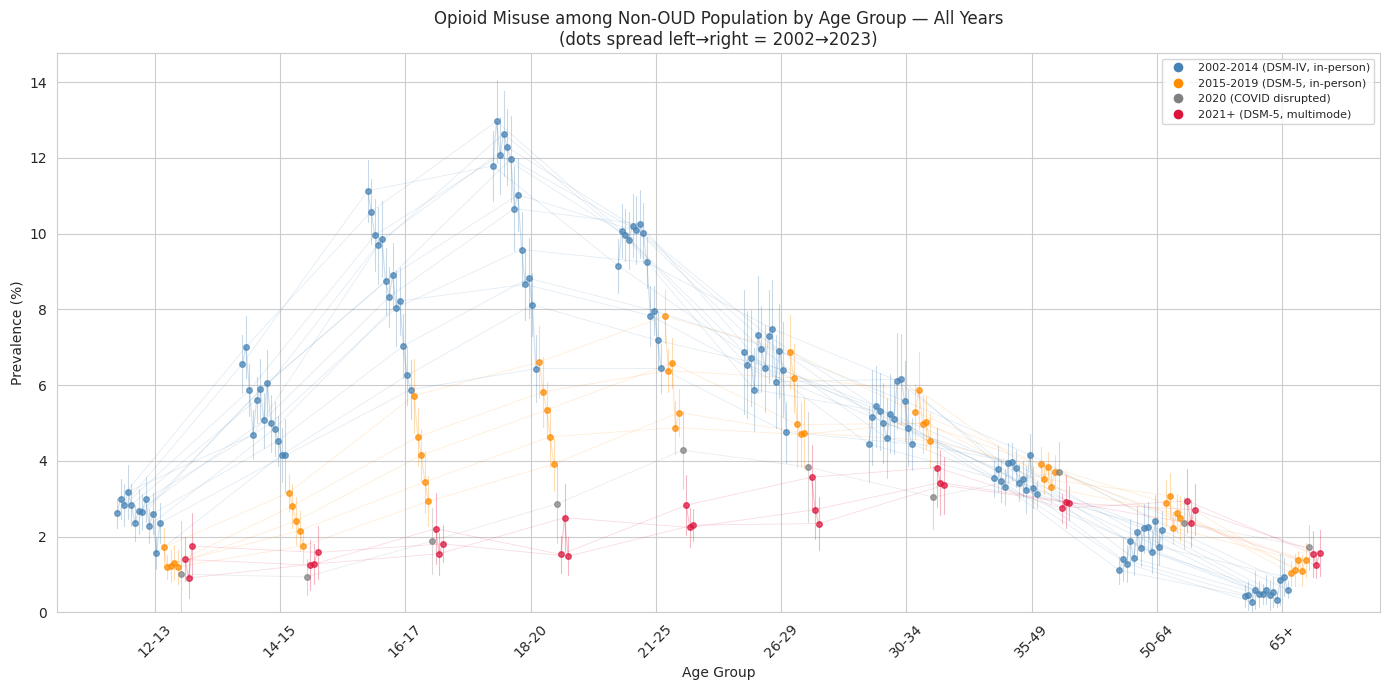

In [8]:
fig = plot_age_profile(results['misuse_no_oud'],
                       'Opioid Misuse among Non-OUD Population')
plt.show()

## Former Opioid Misuse by Age Group

People who report **lifetime** opioid misuse but did **not** misuse in
the past year. This captures former/remitted misusers — people who tried
or used opioids nonmedically at some point but stopped.

- 2015+: lifetime from PNRNMLIF (Rx misuse) or HEREVER (heroin); past-year from OPINMYR
- 2002–2014: lifetime from ANLEVER (analgesic NM use) or HEREVER; past-year from ANLYR | HERYR

Note: the 2015 questionnaire redesign changed how lifetime use was asked,
so the level shift at 2015 partly reflects measurement differences.

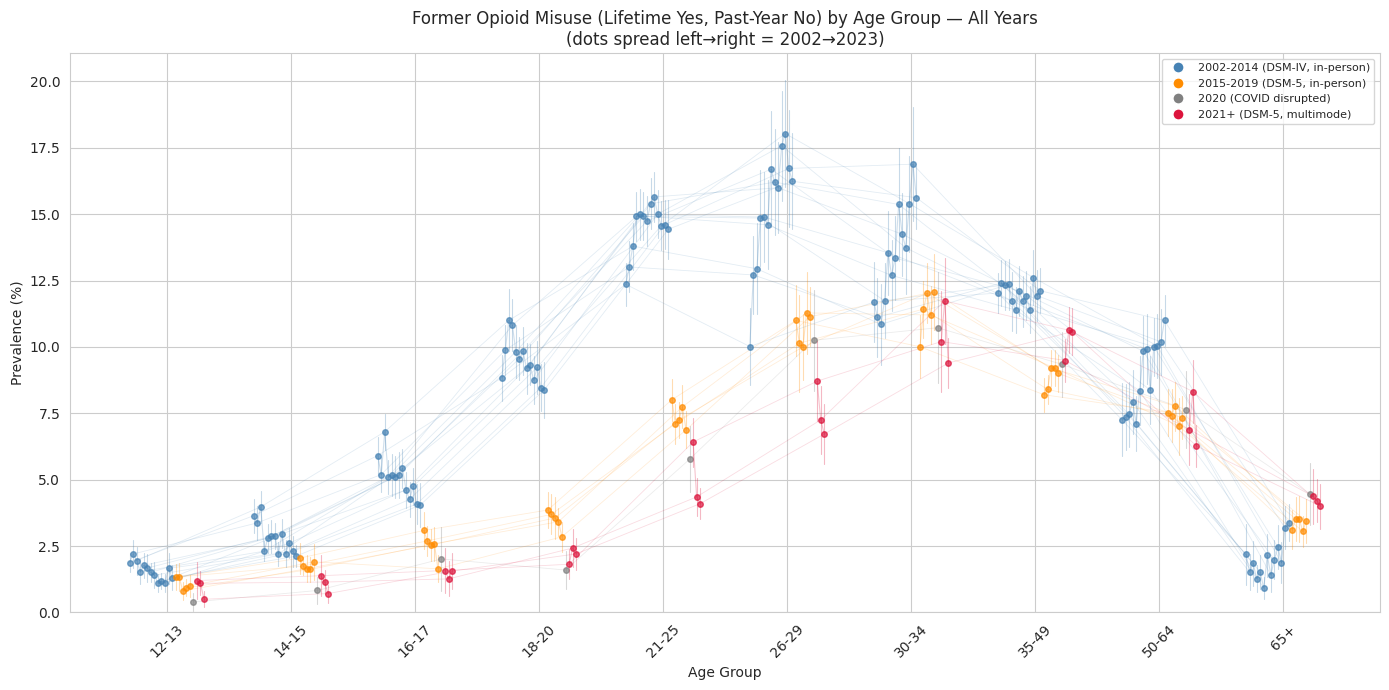

In [9]:
fig = plot_age_profile(results['former_opioid_misuse'],
                       'Former Opioid Misuse (Lifetime Yes, Past-Year No)')
plt.show()

## Side-by-Side Comparison

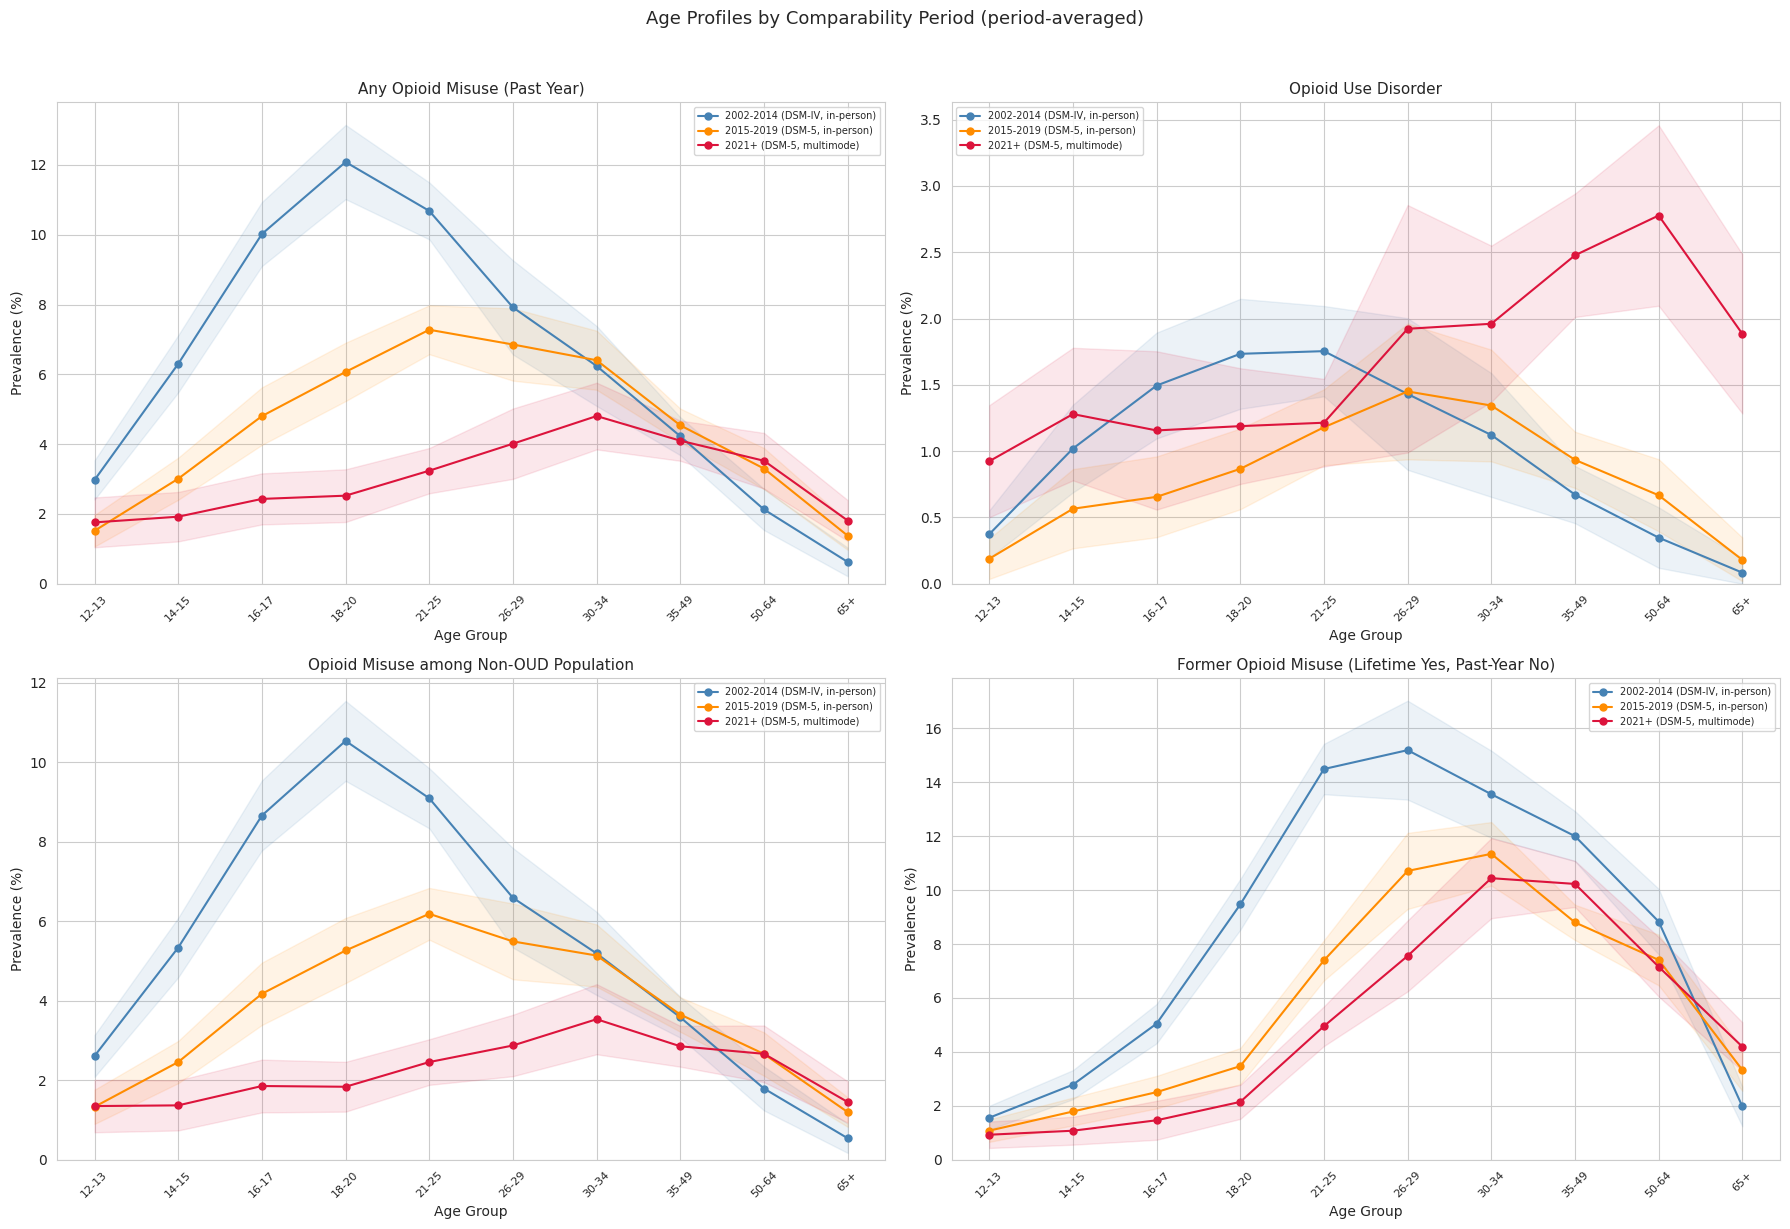

In [10]:
# Side-by-side: overlay period-averaged curves
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=False)
axes = axes.flatten()

period_median_years = {
    '2002-2014 (DSM-IV, in-person)': [2002, 2008, 2014],
    '2015-2019 (DSM-5, in-person)': [2015, 2017, 2019],
    '2021+ (DSM-5, multimode)': [2021, 2022, 2023],
}

for ax, (outcome, label) in zip(axes, outcomes.items()):
    d = results[outcome].copy()
    d['pct'] = d['prev'] * 100
    d['lo'] = d['ci_lo'] * 100
    d['hi'] = d['ci_hi'] * 100
    d['period'] = d['year'].apply(comparability_period)
    d = d.dropna(subset=['age_fine_label', 'pct'])
    d['age_rank'] = d['age_fine_label'].map({a: i for i, a in enumerate(FINE_AGE_ORDER)})
    d = d.dropna(subset=['age_rank'])
    
    for period, color in period_colors.items():
        if period == '2020 (COVID disrupted)':
            continue
        sub = d[d.period == period]
        if len(sub) == 0:
            continue
        # Average across years within this period
        avg = sub.groupby('age_fine_label', as_index=False).agg(
            pct=('pct', 'mean'), lo=('lo', 'mean'), hi=('hi', 'mean'),
            age_rank=('age_rank', 'first')
        ).sort_values('age_rank')
        ax.plot(avg.age_rank, avg.pct, 'o-', color=color, markersize=5,
                linewidth=1.5, label=period)
        ax.fill_between(avg.age_rank, avg.lo, avg.hi, alpha=0.1, color=color)
    
    ax.set_xticks(range(len(FINE_AGE_ORDER)))
    ax.set_xticklabels(FINE_AGE_ORDER, rotation=45, fontsize=8)
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Prevalence (%)')
    ax.set_title(label, fontsize=11)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=7)

plt.suptitle('Age Profiles by Comparability Period (period-averaged)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Interpretation

**Reading the age-profile plots:**
- Each dot = one age group in one survey year
- Within each age-group cluster, dots spread left-to-right by year
- Colors distinguish comparability periods (definition/mode changes)
- Vertical error bars = 95% CI from paired jackknife
- Light within-period lines connect same age group across years (temporal trends)
- Light cross-age lines connect same year across age groups (age profile shape)

**Key patterns to look for:**
- **Age effects**: Which age groups have highest/lowest prevalence?
- **Period effects**: Do all age groups shift together between periods?
- **Cohort effects**: Do diagonal trails (a cohort aging through time) show
  distinctive patterns? For example, a high-prevalence cohort entering the
  18-20 group in 2005 should appear in the 21-25 group around 2008 and
  the 26-29 group around 2012.

**Former opioid misuse:**
- Captures the "resolved" population: people who once misused but stopped
- Prevalence should increase with age (more time to accumulate lifetime exposure)
  and decrease in younger groups (less time to have tried and stopped)
- A cohort that showed high past-year misuse in earlier surveys should show
  up as high former-misuse in later surveys as they age and desist
- The 2015 questionnaire redesign changed lifetime questions, so the level
  shift at 2015 partly reflects measurement differences (ANLEVER → PNRNMLIF)

**Caveats:**
- OUD estimates are NOT comparable across the 2021 break (DSM-IV vs DSM-5)
- The "misuse among non-OUD" outcome inherits both the misuse and OUD
  definition changes, so cross-period comparisons require extra caution
- The 35-49 and 50-64 age groups span wide ranges; cohort tracking is
  imprecise for these groups
- Fine age groups have smaller sample sizes; 95% CIs should be checked